In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
iris = datasets.load_iris()

# iris.target           -> Variável alto
# iris.data             -> Atributos / Características
# iris.feature_names    -> Nomes dos atributos (colunas)

In [5]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [7]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [9]:
# Renomear as colunas

colunas = { 'sepal length (cm)': 'sepal_length',
            'sepal width (cm)': 'sepal_width',
            'petal length (cm)': 'petal_length',
            'petal width (cm)': 'petal_width'}


df = df.rename(columns=colunas)

In [13]:
# Adicionar o target
df['target'] = iris.target

A função map() em Python é usada para aplicar uma função a cada item de um iterável (como uma lista, tupla, etc.) e retornar um iterador com os resultados. No contexto de pandas, a função map() é um método de Series que mapeia os valores de uma Series para outros valores usando um dicionário, uma função ou outra Series.

In [15]:
# Adicionar target_name
df['target_name'] = df.target.map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

In [18]:
# Separação de Treino e Teste
X = df.drop(['target', 'target_name'], axis=1)
y = df.target

O parâmetro random_state na função train_test_split é usado para garantir a reprodutibilidade da divisão entre dados de treino e teste.

Quando você executa train_test_split sem definir random_state, a divisão dos dados será aleatória a cada vez que você executar o código. Isso significa que você obterá conjuntos de treino e teste ligeiramente diferentes em cada execução, o que pode levar a resultados de modelo diferentes.

Ao definir um valor inteiro fixo para random_state (como 42, que é um número frequentemente usado por convenção, embora qualquer número inteiro funcione), a função train_test_split sempre dividirá os dados da mesma maneira, garantindo que você sempre obtenha os mesmos conjuntos de treino e teste. Isso é útil para depuração, comparação de modelos e para garantir que seus resultados sejam consistentes e reprodutíveis.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [21]:
# Instância do modelo SVC

model_svc = SVC()
model_svc = model_svc.fit(X=X_train, y=y_train)

In [22]:
model_svc

SVC()

In [23]:
svc_predict = model_svc.predict(X_test)

In [24]:
accuracy_score(y_test, svc_predict)

1.0

In [28]:
conf_matrix = confusion_matrix(y_test, svc_predict)

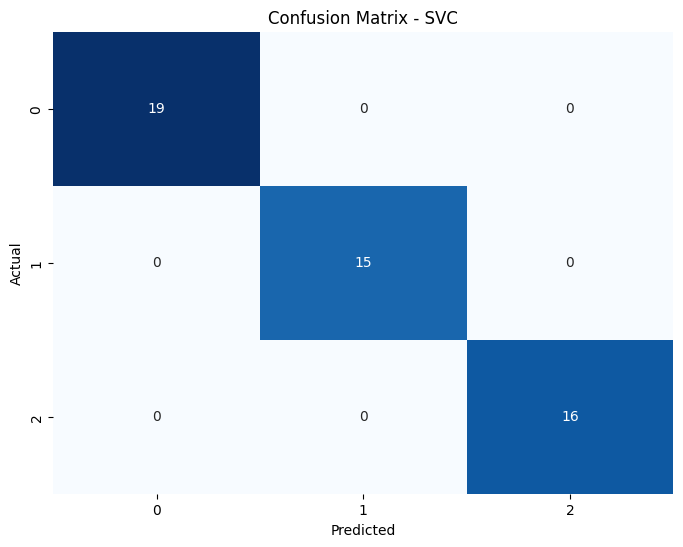

In [29]:
# Criar o mapa de calor da matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)

# Configurar os rótulos
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVC')
plt.show()